In [64]:
import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pyarrow"])


Kernel Python: /Library/Developer/CommandLineTools/usr/bin/python3
Defaulting to user installation because normal site-packages is not writeable
  Using cached pyarrow-21.0.0-cp39-cp39-macosx_12_0_arm64.whl (31.2 MB)


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


0

In [65]:
import sys, pkgutil, platform
print("Kernel Python:", sys.executable)
!which python
!python --version
!pip --version
print("pyarrow found? ->", pkgutil.find_loader("pyarrow") is not None)


Kernel Python: /Library/Developer/CommandLineTools/usr/bin/python3
/Users/mariaoros/miniconda3/bin/python
Python 3.13.5
pip 25.1 from /Users/mariaoros/miniconda3/lib/python3.13/site-packages/pip (python 3.13)
pyarrow found? -> True


In [67]:
!conda activate base
!python -m ipykernel install --user --name base-pyarrow --display-name "Python (base + pyarrow)"



CondaError: Run 'conda init' before 'conda activate'

/Users/mariaoros/miniconda3/bin/python: No module named ipykernel


## Data Exploration

In [69]:
import pandas as pd

In [115]:
df = pd.read_csv('1_Data/exit_velo_project_data.csv')
display(df.head())

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
0,2023,mlb,235,1335,95.7352,47.2362,-6.4422,6.4960,fly_ball,R,R,72,FB,out,32.8
1,2023,mlb,3182,1335,95.9380,4.7291,-4.8052,0.7806,ground_ball,L,R,75,OS,out,29.2
2,2023,mlb,3856,1988,89.1404,-16.2251,15.2382,0.0311,ground_ball,S,R,72,OS,out,29.7
3,2023,mlb,2017,1988,88.7278,-6.8385,-11.5988,0.1215,ground_ball,R,R,69,BB,out,23.4
4,2023,mlb,1594,1988,89.2888,0.5079,-22.1899,0.3802,ground_ball,R,R,73,FB,out,35.3


In [116]:
## Focus on MLB as per business question

df = df[df['level_abbr']=='mlb']

In [117]:
df.dtypes


season             int64
level_abbr        object
batter_id          int64
pitcher_id         int64
exit_velo        float64
launch_angle     float64
spray_angle      float64
hangtime         float64
hit_type          object
batter_hand       object
pitcher_hand      object
batter_height      int64
pitch_group       object
outcome           object
age              float64
dtype: object

In [120]:
df.describe()

,season,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,batter_height,age
count,548689.000000,548689.000000,548689.000000,536356.000000,547234.000000,547236.000000,536474.000000,548689.000000,548689.000000
mean,2021.141373,2071.608977,2230.865089,88.384756,12.331721,-1.291605,2.488877,72.475893,28.667374
std,1.462166,1190.047296,1311.071285,14.779969,28.501101,24.139171,2.284429,2.275439,3.677993
min,2019.000000,2.000000,4.000000,5.244700,-89.684100,-179.868700,0.000500,65.000000,20.000000
25%,2020.000000,1016.000000,1061.000000,79.952800,-5.667375,-18.595325,0.156900,71.000000,26.000000
50%,2021.000000,2120.000000,2249.000000,91.241900,12.849850,-1.561650,1.926900,72.000000,28.300000
75%,2022.000000,3120.000000,3350.000000,99.402000,30.634350,15.574625,4.715200,74.000000,31.100000
max,2023.000000,4127.000000,4490.000000,122.376600,89.875200,179.961800,9.035000,81.000000,43.000000


<Axes: xlabel='outcome'>

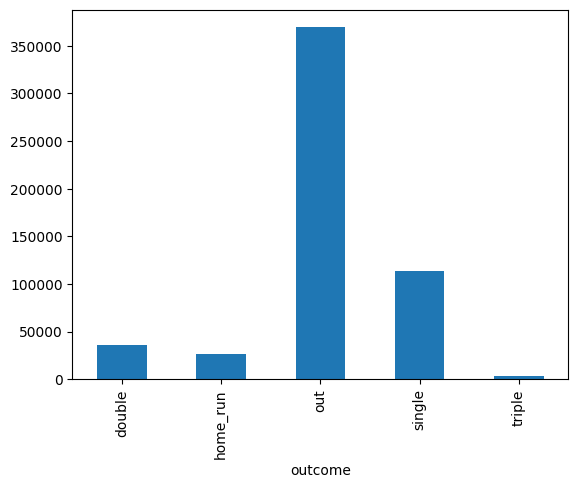

In [121]:
df.groupby('outcome')['batter_id'].count().plot(kind='bar')


<Axes: title={'center': 'Hit Type by outcome'}, xlabel='hit_type'>

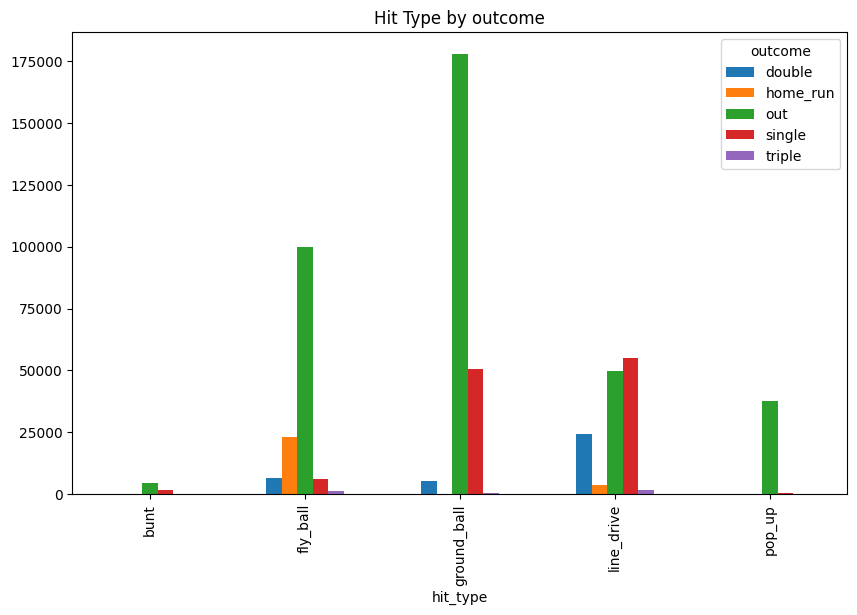

In [122]:

cross_tab = pd.crosstab(df["hit_type"], df["outcome"])
cross_tab.plot(kind="bar", figsize=(10,6), title="Hit Type by outcome")


<Axes: xlabel='batter_hand'>

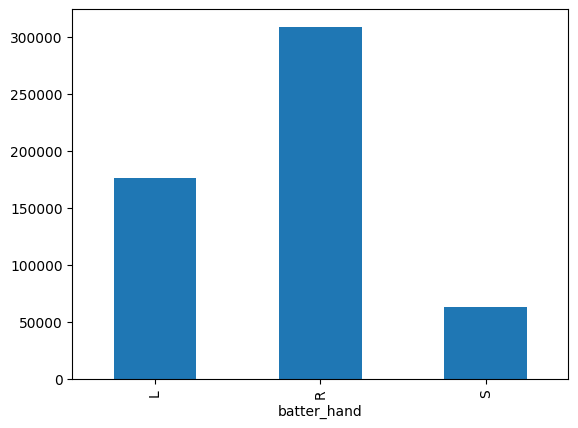

In [123]:
df.groupby('batter_hand')['batter_id'].count().plot(kind='bar')

<Axes: xlabel='hit_type'>

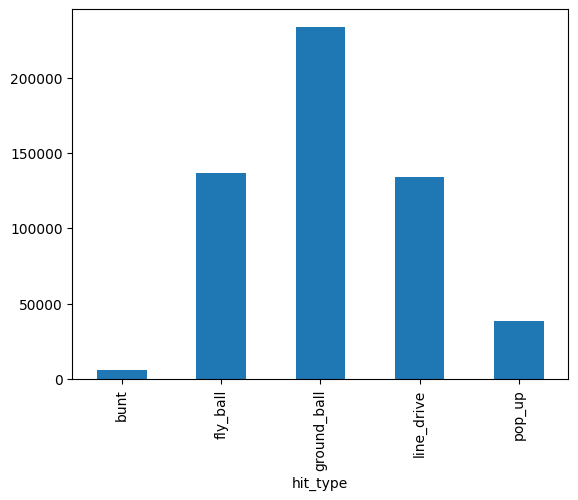

In [124]:
df.groupby('hit_type')['batter_id'].count().plot(kind='bar')

In [125]:
data_dictionary = {
    "season": "Season of the observation",
    "level_abbr": "Level of competition (MLB, AAA, AA)",
    "batter_id": "ID of batter",
    "pitcher_id": "ID of pitcher",
    "exit_velo": "Exit velocity of batted ball in play",
    "launch_angle": "Vertical angle of batted ball in play",
    "spray_angle": "Horizontal angle of batted ball in play",
    "hangtime": "Hangtime of batted ball in play",
    "hit_type": "Hit type (bunt, fly ball, ground ball, line drive, pop up)",
    "batter_hand": "Batter handedness (Right, Left, Switch)",
    "pitcher_hand": "Pitcher handedness (Right, Left)",
    "batter_height": "Height of batter in inches",
    "pitch_group": "Grouped pitch type (Fastball, Breaking ball, Offspeed)",
    "outcome": "Outcome of batted ball in play (out, single, double, triple, home run)",
    "age": "Batter age that season, indexed to July 1"
}

In [126]:
## seasons and batters per season
df.groupby('season')['batter_id'].nunique()

season
2019    909
2020    577
2021    946
2022    685
2023    650
Name: batter_id, dtype: int64

In [127]:
# number of EVENTS per season
df.groupby('season')['batter_id'].count()

season
2019    126902
2020     46507
2021    123412
2022    125855
2023    126013
Name: batter_id, dtype: int64

In [128]:
# Number of batters
df['batter_id'].nunique()

1540

In [129]:
# batter exit velocity over time
df.groupby(['batter_id','season'])['exit_velo'].describe()

count       mean        std      min        25%       50%  \
batter_id season                                                              
2         2023     20.0  92.340940  12.438868  65.7624  84.541400  96.32500   
4         2021     18.0  84.792106   9.615950  68.7793  78.511925  84.18635   
          2022    121.0  83.794632  14.229211  26.9702  74.952500  86.21440   
          2023      1.0  83.400600        NaN  83.4006  83.400600  83.40060   
6         2021    200.0  90.240066  12.590507  53.3034  81.756400  94.55150   
...                 ...        ...        ...      ...        ...       ...   
4121      2021     25.0  72.132392  20.385675  25.4019  62.354400  77.04190   
4124      2019      8.0  79.766575  15.774717  53.8334  69.365150  80.91980   
          2021     11.0  62.297173  28.660359  16.4235  36.806600  80.04030   
4125      2020     16.0  85.981031  17.222138  50.7243  75.995300  92.35665   
4127      2019     22.0  89.043118  11.200344  66.4037  83.041675  90.03565   

                        75%       max  
batter_id season                       
2         2023    101.98655  107.5901  
4         2021     94.39315   96.5718  
          2022     93.56760  105.1161  
          2023     83.40060   83.4006  
6         2021     99.47880  108.1592  
...                     ...       ...  
4121      2021     86.58940  103.2593  
4124      2019     88.55885  101.8190  
          2021     84.77935   97.0309  
4125      2020     99.00030  106.8974  
4127      2019     96.95565  106.7146  

[3767 rows x 8 columns]

In [130]:
# batter exit velocity over time
batter_stats = df.groupby('batter_id')['exit_velo'].describe().reset_index()
batter_stats

,batter_id,count,mean,std,min,25%,50%,75%,max
0,2,20.0,92.340940,12.438868,65.7624,84.541400,96.32500,101.986550,107.5901
1,4,140.0,83.920064,13.646156,26.9702,76.455550,86.17505,93.715450,105.1161
2,6,790.0,87.559909,15.156187,28.1544,79.092650,91.57260,98.953325,109.9484
3,8,2.0,74.939800,0.057134,74.8994,74.919600,74.93980,74.960000,74.9802
4,11,73.0,88.300019,14.130239,27.2274,81.910200,92.89290,98.500000,108.6886
...,...,...,...,...,...,...,...,...,...
1535,4120,6.0,90.378717,14.329490,64.5849,86.798125,94.10535,100.130450,102.9755
1536,4121,33.0,73.304130,20.616967,25.4019,67.157900,77.78900,87.086500,103.2593
1537,4124,19.0,69.652711,25.132448,16.4235,48.960500,80.04030,85.315600,101.8190
1538,4125,16.0,85.981031,17.222138,50.7243,75.995300,92.35665,99.000300,106.8974


In [131]:
# batters with no events
len(batter_stats[batter_stats['count']<1]), batter_stats[batter_stats['count']<1]

(15,
       batter_id  count  mean  std  min  25%  50%  75%  max
 78          202    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 99          275    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 165         438    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 385        1076    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 440        1227    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 443        1236    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 490        1347    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 574        1565    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 670        1812    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 760        2078    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 859        2353    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 942        2555    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1070       2887    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1131       3039    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN
 1491       4007    0.0   NaN  NaN  NaN  NaN  NaN  NaN  NaN)

In [132]:
df[df['batter_id'].isin(batter_stats[batter_stats['count']<1]['batter_id'].values)].groupby(['outcome']).count()

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,age
outcome,,,,,,,,,,,,,,
out,17,17,17,17,0,7,7,0,16,17,17,17,17,17


In [133]:
df.groupby(['outcome']).count()

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,age
outcome,,,,,,,,,,,,,,
double,35875,35875,35875,35875,35775,35853,35853,35767,35875,35875,35875,35875,35875,35875
home_run,26559,26559,26559,26559,26528,26557,26557,26525,26559,26559,26559,26559,26559,26559
out,369463,369463,369463,369463,358482,368304,368305,358546,369434,369463,369463,369463,369463,369463
single,113719,113719,113719,113719,112506,113451,113452,112571,113690,113719,113719,113719,113719,113719
triple,3073,3073,3073,3073,3065,3069,3069,3065,3073,3073,3073,3073,3073,3073


In [135]:
df[df['batter_id']==6]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
394,2023,mlb,6,620,97.5291,8.7833,18.4558,1.3190,line_drive,R,L,72,BB,single,28.2
408,2023,mlb,6,3041,88.8571,24.5141,20.3835,3.7933,line_drive,R,R,72,BB,out,28.2
597,2023,mlb,6,620,79.4581,-3.6750,-37.9217,0.2618,ground_ball,R,L,72,FB,out,28.2
613,2023,mlb,6,620,76.5631,33.9603,-1.8987,4.3951,fly_ball,R,L,72,FB,out,28.2
622,2023,mlb,6,3041,75.5433,29.0082,17.7991,3.6652,line_drive,R,R,72,BB,out,28.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372513,2021,mlb,6,3089,99.6516,46.4625,21.4187,6.4142,fly_ball,R,R,72,BB,out,26.2
373582,2021,mlb,6,1370,78.0334,-33.6009,-54.5653,0.0336,ground_ball,R,L,72,OS,out,26.2
373596,2021,mlb,6,1450,100.3661,32.0385,-8.7987,5.7611,fly_ball,R,R,72,BB,home_run,26.2
373968,2021,mlb,6,3544,56.5729,8.4836,-4.1280,0.8563,ground_ball,R,R,72,FB,out,26.2


<Axes: >

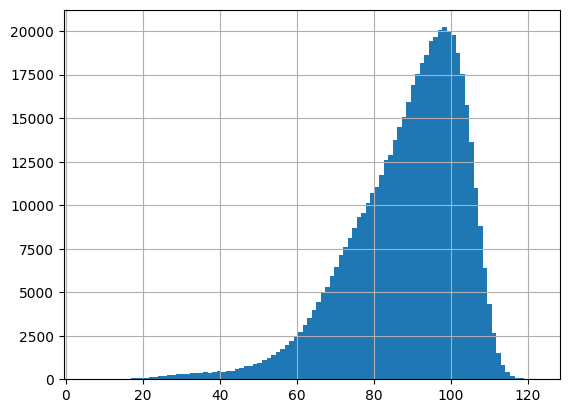

In [136]:
## Distribution of exit velocity
df[('exit_velo')].hist(bins=100)

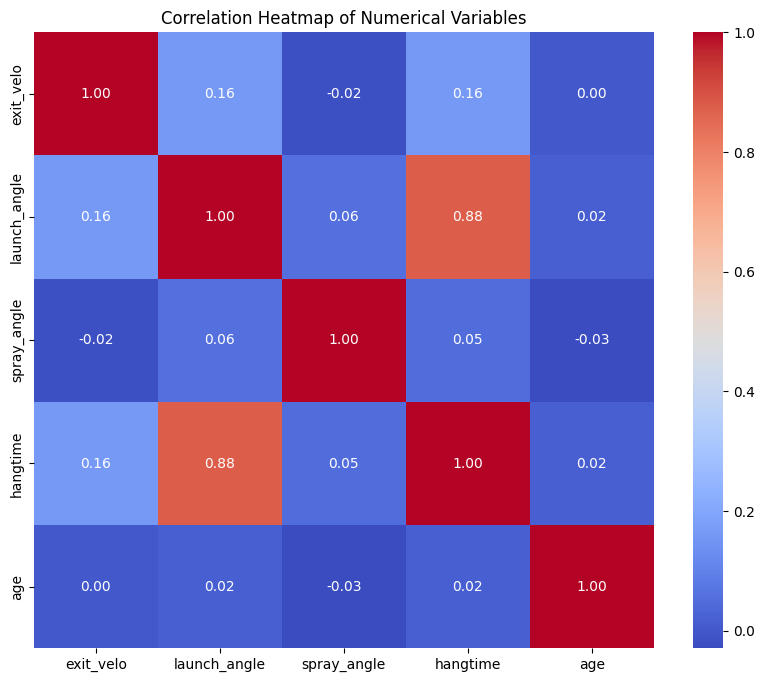

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_df = df.select_dtypes(include=['float64'])
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

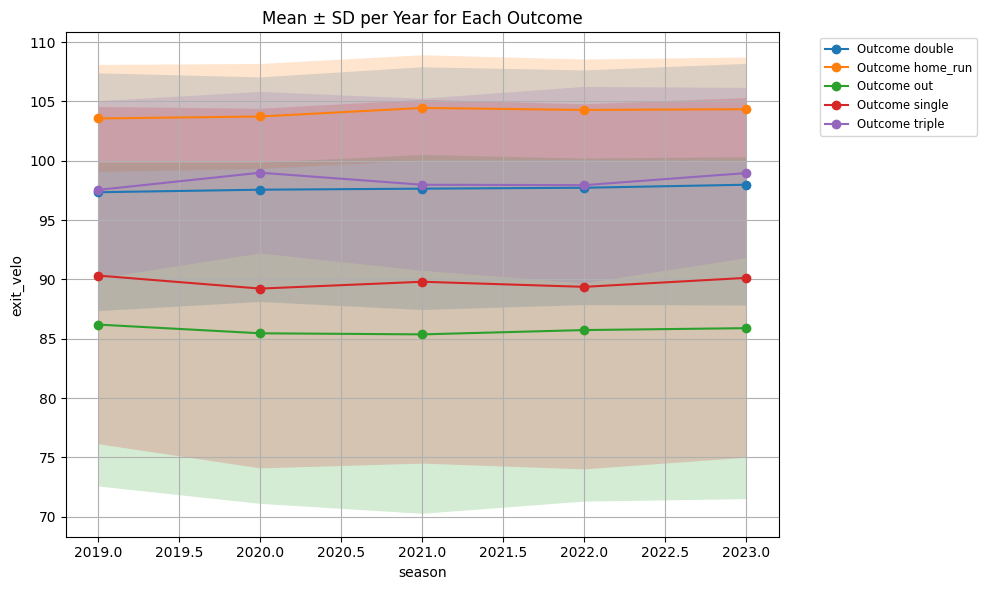

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df.groupby(["season", "outcome"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("outcome"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Outcome {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each Outcome")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


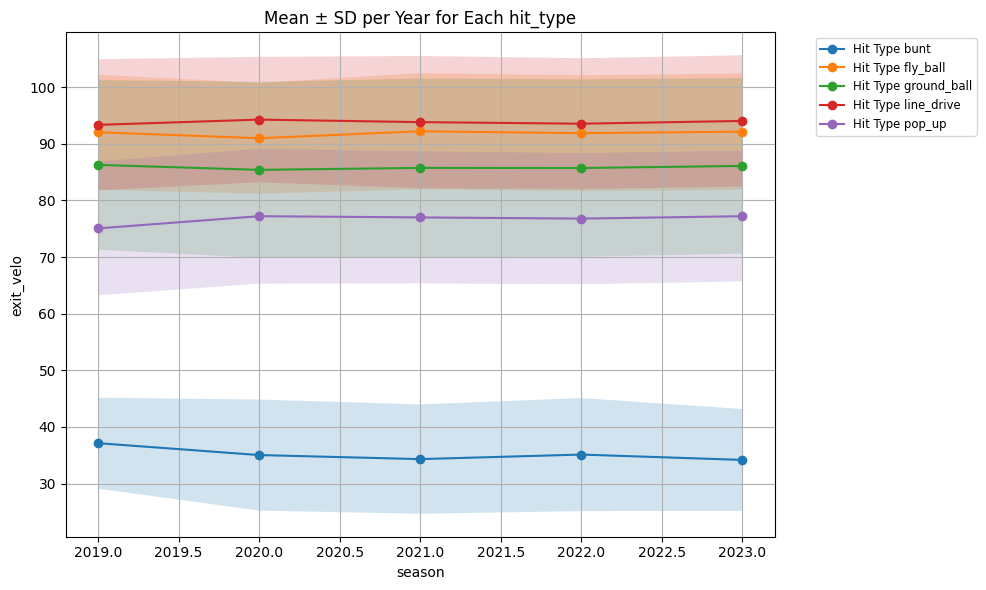

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df.groupby(["season", "hit_type"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("hit_type"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Hit Type {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each hit_type")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


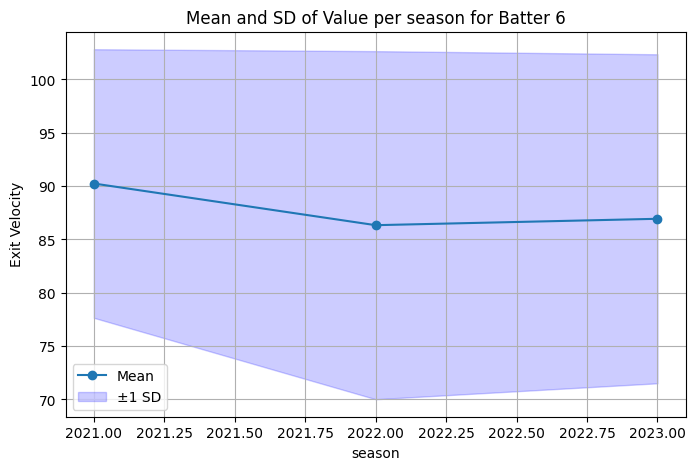

In [140]:
import pandas as pd
import matplotlib.pyplot as plt


stats = df[df['batter_id']==6].groupby("season")["exit_velo"].agg(["mean", "std"]).reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(stats["season"], stats["mean"], marker="o", label="Mean")
plt.fill_between(
    stats["season"],
    stats["mean"] - stats["std"],
    stats["mean"] + stats["std"],
    color="blue",
    alpha=0.2,
    label="±1 SD"
)
plt.xlabel("season")
plt.ylabel("Exit Velocity")
plt.title("Mean and SD of Value per season for Batter 6")
plt.legend()
plt.grid(True)
plt.show()


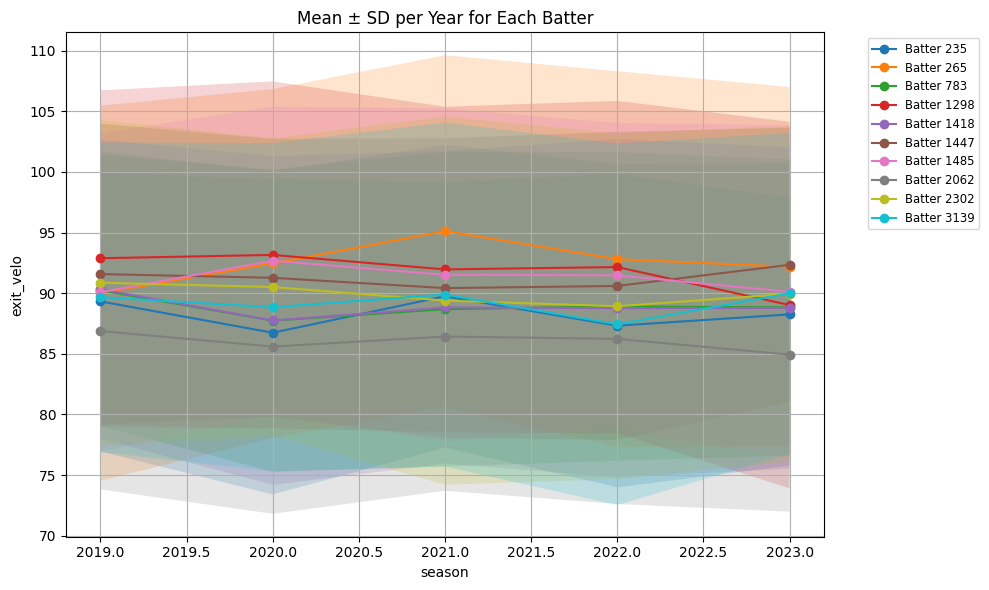

In [141]:
import pandas as pd
import matplotlib.pyplot as plt

## Aggregated per batter_id
stats = (
    df[df['batter_id'].isin([235,1485,2302,2062,3139,783,1447,265,1418,1298
])].groupby(["season", "batter_id"])["exit_velo"]
      .agg(["mean", "std"])
      .reset_index()
)

# Plot each batter’s line
plt.figure(figsize=(10, 6))
for batter_id, g in stats.groupby("batter_id"):
    plt.plot(g["season"], g["mean"], marker="o", label=f"Batter {batter_id}")
    plt.fill_between(
        g["season"],
        g["mean"] - g["std"],
        g["mean"] + g["std"],
        alpha=0.2
    )

plt.xlabel("season")
plt.ylabel("exit_velo")
plt.title("Mean ± SD per Year for Each Batter")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.grid(True)
plt.tight_layout()
plt.show()


In [142]:
set(df.outcome)

{'double', 'home_run', 'out', 'single', 'triple'}

In [144]:
df[df['batter_id'].isin([235])]

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age
0,2023,mlb,235,1335,95.7352,47.236200,-6.442200,6.4960,fly_ball,R,R,72,FB,out,32.8
17,2023,mlb,235,1335,102.3143,6.828800,-21.681000,1.0272,ground_ball,R,R,72,BB,out,32.8
38,2023,mlb,235,436,93.3415,5.930500,14.926900,1.0638,ground_ball,R,R,72,FB,single,32.8
46,2023,mlb,235,2973,99.2878,24.902300,-17.505600,5.0018,fly_ball,R,R,72,FB,home_run,32.8
49,2023,mlb,235,1432,103.8804,-0.798800,-24.461800,0.3326,ground_ball,R,L,72,FB,out,32.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547650,2019,mlb,235,2906,86.2791,47.305300,-0.857000,5.6830,fly_ball,R,R,72,FB,out,28.8
547666,2019,mlb,235,2906,NaN,-29.644301,-1.022277,NaN,ground_ball,R,R,72,BB,single,28.8
547679,2019,mlb,235,2438,88.1097,78.436600,-25.106000,6.8022,pop_up,R,R,72,FB,out,28.8
548186,2019,mlb,235,2321,103.4463,33.654700,-7.715700,5.7864,fly_ball,R,R,72,FB,home_run,28.8


## First model approach

In [152]:
!pip install statsmodels

  Using cached statsmodels-0.14.5-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]


In [155]:
df.columns

Index(['season', 'level_abbr', 'batter_id', 'pitcher_id', 'exit_velo',
       'launch_angle', 'spray_angle', 'hangtime', 'hit_type', 'batter_hand',
       'pitcher_hand', 'batter_height', 'pitch_group', 'outcome', 'age'],
      dtype='object')

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I will do inference for a single clase of batter id with data for all seasons

all_seasons = set(df["season"].unique())

# Group by batter_id and check seasons
batters_all_seasons = (
    df.groupby("batter_id")["season"]
      .apply(lambda x: set(x.unique()) == all_seasons)
)

# Filter those batter_ids
valid_batters = batters_all_seasons[batters_all_seasons].index

# Subset dataset to only those batters
df_valid = df[df["batter_id"].isin(valid_batters)]
df_valid

,season,level_abbr,batter_id,pitcher_id,exit_velo,launch_angle,spray_angle,hangtime,hit_type,batter_hand,pitcher_hand,batter_height,pitch_group,outcome,age,year
year,,,,,,,,,,,,,,,,
2023-01-01,2023,mlb,235,1335,95.7352,47.236200,-6.442200,6.4960,fly_ball,R,R,72,FB,out,32.8,2023-01-01
2023-01-01,2023,mlb,3182,1335,95.9380,4.729100,-4.805200,0.7806,ground_ball,L,R,75,OS,out,29.2,2023-01-01
2023-01-01,2023,mlb,3856,1988,89.1404,-16.225100,15.238200,0.0311,ground_ball,S,R,72,OS,out,29.7,2023-01-01
2023-01-01,2023,mlb,1594,1988,89.2888,0.507900,-22.189900,0.3802,ground_ball,R,R,73,FB,out,35.3,2023-01-01
2023-01-01,2023,mlb,1723,1335,68.7987,-39.227200,43.607500,0.0299,ground_ball,L,R,76,FB,out,28.0,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-01,2019,mlb,1058,2733,NaN,NaN,NaN,NaN,bunt,R,R,71,FB,out,25.1,2019-01-01
2019-01-01,2019,mlb,2424,2733,80.7754,33.744000,-9.085700,4.6743,fly_ball,R,R,70,FB,out,24.0,2019-01-01
2019-01-01,2019,mlb,2505,2733,NaN,63.635016,26.660205,NaN,pop_up,L,R,76,OS,out,33.6,2019-01-01


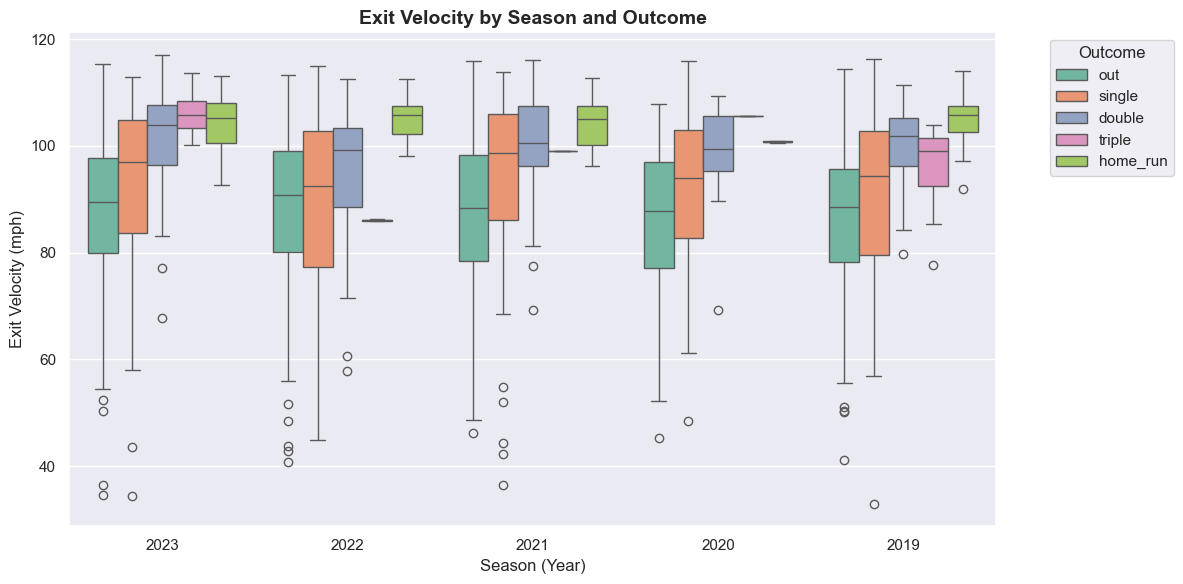

In [187]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

btc = (
    df.loc[df['batter_id'] == 3856, ['season', 'outcome', 'exit_velo','hit_type']]
      .dropna(subset=['season', 'outcome', 'exit_velo','hit_type'])
      .copy()
)

# Ensure columns are unique (paranoia check)
assert not btc.columns.duplicated().any(), "Duplicate column names detected."

# Make the index simple & unique
btc = btc.reset_index(drop=True)

# (Optional) normalize dtypes for categorical plotting
btc['season'] = btc['season'].astype(str)   # or .astype('category')
btc['outcome'] = btc['outcome'].astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=btc,
    x="season",
    y="exit_velo",
    hue="outcome",
    palette="Set2"
)
plt.title("Exit Velocity by Season and Outcome", fontsize=14, weight="bold")
plt.xlabel("Season (Year)", fontsize=12)
plt.ylabel("Exit Velocity (mph)", fontsize=12)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


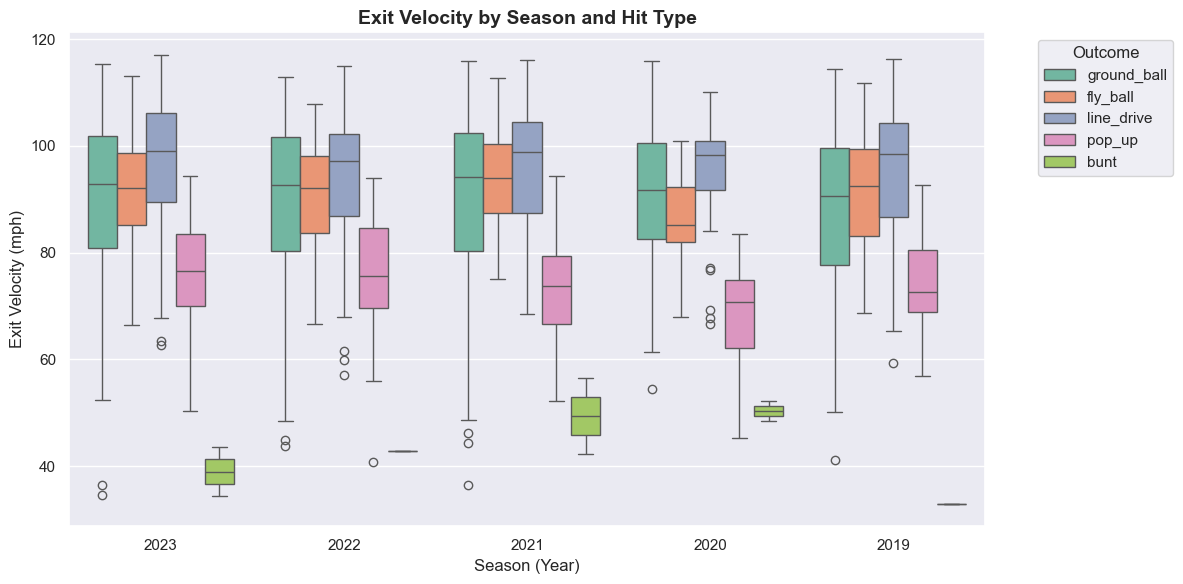

In [188]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Make the index simple & unique
btc = btc.reset_index(drop=True)

# (Optional) normalize dtypes for categorical plotting
btc['hit_type'] = btc['hit_type'].astype(str)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=btc,
    x="season",
    y="exit_velo",
    hue="hit_type",
    palette="Set2"
)
plt.title("Exit Velocity by Season and Hit Type", fontsize=14, weight="bold")
plt.xlabel("Season (Year)", fontsize=12)
plt.ylabel("Exit Velocity (mph)", fontsize=12)
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


ImportError: cannot import name 'gaussian' from 'scipy.signal' (/Users/mariaoros/Library/Python/3.9/lib/python/site-packages/scipy/signal/__init__.py)